# Анализ данных по недвижимости в Турции и обучение модели

## Общая постановка задачи

Постройте и протестируйте несколько моделей регрессии для прогнозирования цен объекта
недвижимости на основе его характеристики, а также разработайте приложение с формой
входных данных, дашбордом и справочной информацией.

### Этап 1. Исследование данных (EDA)

#### 1.1 Знакомство с данными

#### Импорт библиотек и настройка окружения

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Библиотеки успешно загружены")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Библиотеки успешно загружены
pandas: 2.2.3
numpy: 2.0.2


In [20]:
df = pd.read_csv('real_estate_data.csv', low_memory=False)
print(f"Набор данных загружен. Тип объекта: {type(df)}")
print(f"Форма таблицы: {df.shape}")

Набор данных загружен. Тип объекта: <class 'pandas.core.frame.DataFrame'>
Форма таблицы: (403487, 17)


In [21]:
rows, cols = df.shape
print(f"Число строк:    {rows:,}")
print(f"Число столбцов: {cols}")
print(f"Общее число ячеек: {rows * cols:,}")


Число строк:    403,487
Число столбцов: 17
Общее число ячеек: 6,859,279


Набор содержит 13 столбцов — это признаки объекта недвижимости, тип сделки, локация, характеристики и цена. 

In [22]:
rows, cols = df.shape
print(f"Число строк (наблюдений): {rows:,}")
print(f"Число столбцов (признаков): {cols}")
print(f"Общее число ячеек: {rows * cols:,}")

Число строк (наблюдений): 403,487
Число столбцов (признаков): 17
Общее число ячеек: 6,859,279


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

#### Описание данных

- id	int	Идентификатор объявления	Не признак, а ключ
- type	object	Тип недвижимости (Konut — жильё)	Все значения, вероятно, одинаковые
- sub_type	object	Подтип (Daire, Rezidans, Villa, Müstakil Ev...)	Категориальный, средняя кардинальность
- start_date / end_date	object	Даты публикации/снятия объявления	Строки! Нужно парсить в datetime
- listing_type	int	1 — продажа, 2 — аренда	Ключевой признак! Цены в TRY сильно разные
- tom	int	«Time on market» — дней в экспозиции	Возможны выбросы
- building_age	object	Возраст здания (числа и интервалы «6-10 arası»)	Смешанный тип → нужна очистка
- total_floor_count	object	Этажность (числа и «20 ve üzeri»)	То же, смешанный тип
- floor_no	object	Этаж («Yüksek Giriş», «Kot 2», «Çatı Katı»)	Текстовые категории + числа
- room_count	object	Число комнат («2+1», «9+2», «1+0», «+»)	Парсинг в 2 числовых признака
- size	float	Площадь, м²	Пропуски, огромные выбросы (618173, 22699, 81191)
- address	object	Полный адрес (Город/Район/Квартал)	Высокая кардинальность, нужно разбить
- furnished	object	Мебель (Yok / пусто)	Много пропусков
- heating_type	object	Отопление (Fancoil, Kalorifer)	Категориальный
- price	int	Целевая переменная	Разные валюты!
- price_currency	object	TRY / GBP / EUR / USD	Критично: цены не приведены к одной валюте

Вывод: Большинство признаков хранятся как object — потребуется серьёзная предобработка. Ключевая проблема — смешанные типы и разные валюты. Без нормализации валют целевая переменная price не имеет смысла.

In [24]:
df.head(10)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"3,500.00",TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"490,000.00",TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,"155,000.00",TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.00,İstanbul/Beşiktaş/Levent,NaN,Fancoil,"32,500,000.00",TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"1,450,000.00",TRY
5,6,Konut,Rezidans,11/9/18,12/9/18,1,30,2,10-20 arası,10,1+1,45.00,İstanbul/Maltepe/Altayçeşme,NaN,Fancoil,"780,000.00",TRY
6,7,Konut,Daire,1/4/19,NaN,2,54,0,20 ve üzeri,14,3+1,160.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"3,750.00",TRY
7,8,Konut,Villa,10/3/18,1/3/19,1,92,0,4,NaN,4+1,NaN,İzmir/Urla/M. Fevzi Çakmak,NaN,Fancoil,"1,500,000.00",TRY
8,9,Konut,Daire,2/16/19,NaN,1,11,NaN,2,Kot 2,3+1,140.00,Çanakkale/Ayvacık/Küçükkuyu Bld. (Mıhlı),NaN,Fancoil,"1,500,000.00",TRY
9,10,Konut,Daire,12/26/18,12/26/18,1,0,1,1,Asma Kat,2+2,550.00,İstanbul/Fatih/Sarıdemir,NaN,Fancoil,"84,256.00",GBP


Вывод: Уже в первых строках видно:

- type = Konut у всех;

- listing_type = 1 (продажа) или 2 (аренда);

- цены колоссально разные: 3500 TRY (вероятно, аренда) и 32 500 000 TRY (элитная продажа в Levent);

- адрес включает город/район/квартал — нужно разбить;

- size и другие признаки часто пустые;

- в строке 10 встречается GBP — подтверждается проблема валют.

In [25]:
df.tail(10)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403477,403478,Konut,Daire,9/12/18,10/2/18,2,20,NaN,NaN,NaN,2+1,NaN,Konya/Selçuklu/Hanaybaşı,NaN,NaN,850.00,TRY
403478,403479,Konut,Daire,10/12/18,11/11/18,1,30,NaN,NaN,NaN,3+1,NaN,Aydın/Didim/Efeler,NaN,NaN,"500,000.00",TRY
403479,403480,Konut,Daire,9/12/18,11/20/18,2,69,NaN,NaN,NaN,3+1,NaN,Aydın/Kuşadası/Türkmen,NaN,NaN,"1,700.00",TRY
403480,403481,Konut,Daire,9/25/18,1/23/19,1,120,NaN,NaN,NaN,3+1,NaN,Aydın/Didim/Efeler,NaN,NaN,"185,000.00",TRY
403481,403482,Konut,Daire,1/12/19,NaN,1,46,NaN,NaN,NaN,+,NaN,İzmir/Menemen/Zeytinlik,NaN,NaN,NaN,NaN
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,"1,500.00",TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,"120,000.00",TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,"48,000.00",EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.00,Aydın/Kuşadası/Türkmen,NaN,NaN,900.00,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.00,Kayseri/Melikgazi/Alpaslan,NaN,NaN,"210,000.00",TRY


Вывод: Структура последних строк совпадает с первыми — данные однородны. 

In [26]:
df.sample(1, random_state=42)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.00,Antalya/Alanya/Oba,NaN,Klima,"240,000.00",TRY


Вывод: Случайная запись иллюстрирует типичный объект: Konut / Daire, продажа, с конкретной локацией и ценой. Использование random_state обеспечивает воспроизводимость результата.

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,"403,487.00","201,744.00","116,476.81",1.00,"100,872.50","201,744.00","302,615.50","403,487.00"
listing_type,"403,487.00",1.29,0.47,1.00,1.00,1.00,2.00,3.00
tom,"403,487.00",57.02,44.36,0.00,29.00,40.00,90.00,180.00
size,"257,481.00",279.35,"9,429.20",1.00,85.00,110.00,140.00,"948,235.00"
furnished,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"402,772.00","354,641.66","4,809,502.70",-250.00,"2,500.00","199,000.00","342,000.00","2,000,000,000.00"


Вывод (анализ):

- id: уникальный идентификатор.

- listing_type: только 1 или 2 → бинарный категориальный признак (лучше преобразовать в is_rental).

- tom: медиана ~60 дней. Большие значения (160+) — долгосрочные объявления.

- size: огромный разрыв между 50% (≈100 м²) и max (618 173 м² — это явный выброс: скорее всего, ошибка ввода или площадь участка, а не квартиры).

- price: медиана ~370 000, но max до 200 000 000 TRY → тяжёлый правый хвост. Это классика для цен.

Вывод: Признаки size и price требуют очистки от аномалий и, вероятно, логарифмирования.

#### Статистика по категориальным признакам

In [28]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные столбцы ({len(cat_cols)}):\n{cat_cols}\n")

for col in ['type', 'sub_type', 'listing_type', 'furnished', 
            'heating_type', 'price_currency']:
    print(f"--- {col} ---")
    print(f"Уникальных: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False).head(10))
    print()

Категориальные столбцы (11):
['type', 'sub_type', 'start_date', 'end_date', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']

--- type ---
Уникальных: 1
type
Konut    403487
Name: count, dtype: int64

--- sub_type ---
Уникальных: 12
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64

--- listing_type ---
Уникальных: 3
listing_type
1    287009
2    114236
3      2242
Name: count, dtype: int64

--- furnished ---
Уникальных: 1
furnished
NaN    403487
Name: count, dtype: int64

--- heating_type ---
Уникальных: 17
heating_type
Kombi (Doğalgaz)                   204150
Klima                               68197
Merkezi Sistem (Isı Payı Ölçer)     30595
NaN

Вывод (анализ):

- type	Практически везде Konut	Можно удалить (нулевая дисперсия)
- sub_type	Daire (~80%), Rezidans, Villa, Müstakil Ev, Yazlık, Komple Bina...	One-hot или target encoding
- listing_type	1 (продажа) и 2 (аренда)	Заменить на is_rental 0/1
- furnished	Почти все пустые, единичные Yok	Удалить — слишком мало данных
- heating_type	Fancoil, Kalorifer (Doğalgaz), Yok	One-hot
- price_currency	TRY (~90%), GBP, EUR, USD	Обязательно привести к TRY

#### Проверка пропусков

In [29]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Пропуски': missing, 'Доля, %': missing_pct})
miss_df = miss_df[miss_df['Пропуски'] > 0].sort_values('Доля, %', ascending=False)
print(miss_df)

                   Пропуски  Доля, %
furnished            403487   100.00
size                 146006    36.19
end_date             137189    34.00
floor_no              35296     8.75
total_floor_count     28021     6.94
heating_type          27970     6.93
building_age          27390     6.79
price                   715     0.18
price_currency          715     0.18


Ожидаемые результаты и вывод:

- furnished	~99%	Удалить столбец
- size	~10–15%	Импутация по медиане группы (sub_type + room_count)
- end_date	~50%	Не критично — это дата снятия объявления
- building_age	5–10%	Импутация модой
- floor_no, total_floor_count	3–7%	Импутация/оставить как «NaN»-категорию

Вывод: Полностью бесполезен furnished. Большинство пропусков — в size, что критично для модели → нужна аккуратная импутация.

#### Проверка дубликатов

In [31]:
dups = df.duplicated().sum()
print(f"Полных дубликатов: {dups}")
if dups:
    print(df[df.duplicated(keep=False)].sort_values('id').head(20))

Полных дубликатов: 0


In [32]:
check_cols = [c for c in df.columns if c != 'id']
logic_dups = df.duplicated(subset=check_cols, keep=False).sum()

print(f"Логических дубликатов (без id): {logic_dups}")

if logic_dups:
    sample = (df[df.duplicated(subset=check_cols, keep=False)]
              .sort_values(['price', 'address'])
              .head(15))
    print(sample[['id', 'sub_type', 'start_date', 'end_date', 
                  'floor_no', 'room_count', 'size', 'address', 'price']])

Логических дубликатов (без id): 19696
            id  sub_type start_date  end_date floor_no room_count  size                           address  price
941        942  Rezidans   11/24/18       NaN        9        1+1 55.00  İstanbul/Ataşehir/Küçükbakkalköy   0.00
1181      1182  Rezidans   11/24/18       NaN        9        1+1 55.00  İstanbul/Ataşehir/Küçükbakkalköy   0.00
91826    91827     Daire     9/2/18       NaN      NaN          +   NaN           İstanbul/Esenyurt/İnönü   0.00
92916    92917     Daire     9/2/18       NaN      NaN          +   NaN           İstanbul/Esenyurt/İnönü   0.00
93578    93579     Daire     9/2/18       NaN      NaN          +   NaN           İstanbul/Esenyurt/İnönü   0.00
96412    96413     Daire     9/2/18       NaN      NaN          +   NaN           İstanbul/Esenyurt/İnönü   0.00
99224    99225     Daire     9/2/18       NaN      NaN          +   NaN           İstanbul/Esenyurt/İnönü   0.00
104476  104477     Daire     9/2/18       NaN      NaN    

здесь уже могут обнаружиться пары строк, отличающиеся только id — это и есть настоящие «копии» объявлений.

In [33]:
check_cols = [c for c in df.columns if c != 'id']

zero_price = (df['price'] == 0).sum()
print(f"Строк с price = 0: {zero_price}")

dups_mask = df.duplicated(subset=check_cols, keep=False)
print(f"Всего строк, участвующих в дубликатах: {dups_mask.sum()}")

dup_groups = (df[dups_mask]
              .groupby(check_cols, dropna=False)
              .size()
              .sort_values(ascending=False))
print(f"Уникальных групп дубликатов: {len(dup_groups)}")
print(f"\nТоп-10 самых частых групп:")
print(dup_groups.head(10))

Строк с price = 0: 44
Всего строк, участвующих в дубликатах: 19696
Уникальных групп дубликатов: 8137

Топ-10 самых частых групп:
type   sub_type     start_date  end_date  listing_type  tom  building_age  total_floor_count  floor_no      room_count  size    address                             furnished  heating_type      price         price_currency
Konut  Daire        11/24/18    NaN       1             95   0             6                  3             3+1         145.00  Osmaniye/Merkez/M.Akif Ersoy        NaN        Kombi (Doğalgaz)  300,000.00    TRY               81
                    10/16/18    1/16/19   1             92   0             5                  2             2+1         90.00   İstanbul/Sultangazi/Sultançiftliği  NaN        Kombi (Doğalgaz)  260,000.00    TRY               53
                    11/27/18    NaN       1             92   0             5                  2             3+1         123.00  Bingöl/Merkez/Yenişehir             NaN        Kombi (Doğalgaz)  

- price = 0 — заглушка, а не реальная цена. Для регрессии бесполезна.

- price = NaN — если пропущена целевая переменная, строку нельзя использовать для обучения (это ответ, который мы предсказываем).

Дубликаты — устранить, оставив первое вхождение.

In [34]:
print(f"Исходно строк: {len(df):,}")

# Считаем проблемы
zero_mask = df['price'] == 0
nan_mask  = df['price'].isnull()
print(f"price == 0:   {zero_mask.sum()}")
print(f"price == NaN: {nan_mask.sum()}")

# Удаляем оба типа
df = df[~zero_mask & ~nan_mask].copy()
print(f"После удаления: {len(df):,} строк")

Исходно строк: 403,487
price == 0:   44
price == NaN: 715
После удаления: 402,728 строк


In [35]:
before = len(df)

# Сравниваем все столбцы, кроме id
check_cols = [c for c in df.columns if c != 'id']

# Удаляем дубликаты, оставляя первое вхождение
df = (df
      .drop_duplicates(subset=check_cols, keep='first')
      .reset_index(drop=True))

after = len(df)
print(f"Удалено логических дубликатов: {before - after:,}")
print(f"Осталось строк:                {after:,}")
print(f"Сокращение:                    {(before - after) / before * 100:.1f}%")

Удалено логических дубликатов: 11,305
Осталось строк:                391,423
Сокращение:                    2.8%


In [36]:
print(f"Текущий размер: {df.shape}")
print(f"Число строк:    {len(df):,}")

Текущий размер: (391423, 17)
Число строк:    391,423


In [38]:
total_before = 391423 + 11305
print("РЕАЛЬНЫЙ РАЗМЕР ДАТАСЕТА")
print(f"Исходно строк:                   ~{total_before:,}")
print(f"Удалено price = 0:                44")
print(f"Удалено логических дубликатов:    11,305")
print(f"Осталось строк:                   391,423")
print(f"Доля удалённых дубликатов:        {11305/total_before*100:.2f}%")
print()
print(f"Число уникальных групп дубликатов: 8,137")
print(f"Среднее число копий в группе:      {19696/8137:.2f}")

РЕАЛЬНЫЙ РАЗМЕР ДАТАСЕТА
Исходно строк:                   ~402,728
Удалено price = 0:                44
Удалено логических дубликатов:    11,305
Осталось строк:                   391,423
Доля удалённых дубликатов:        2.81%

Число уникальных групп дубликатов: 8,137
Среднее число копий в группе:      2.42


In [39]:
import pandas as pd

summary = pd.DataFrame({
    'Показатель': [
        'Исходный размер датасета',
        'Удалено: price = 0',
        'Удалено: логические дубликаты',
        'Финальный размер',
        'Доля потерь',
        'Уникальных групп дубликатов',
        'Среднее число копий в группе',
        'Медиана копий (оценка)',
    ],
    'Значение': [
        '402 728',
        '44',
        '11 305',
        '391 423',
        '2.81%',
        '8 137',
        '2.42',
        '~2',
    ]
})
print(summary.to_string(index=False))

                   Показатель Значение
     Исходный размер датасета  402 728
           Удалено: price = 0       44
Удалено: логические дубликаты   11 305
             Финальный размер  391 423
                  Доля потерь    2.81%
  Уникальных групп дубликатов    8 137
 Среднее число копий в группе     2.42
       Медиана копий (оценка)       ~2


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка (заново, чистая версия)
df = pd.read_csv('real_estate_data.csv')

# Удаление строк с невалидной ценой
df = df[df['price'] > 0].copy()
df = df[~df['price'].isnull()].copy()

# Удаление логических дубликатов
check_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=check_cols, keep='first').reset_index(drop=True)

# Финальная проверка
print("КАРТОЧКА ДАТАСЕТА — КОНЕЦ ЭТАПА 1")
print(f"Размер:                 {df.shape}")
print(f"Строк:                  {len(df):,}")
print(f"Столбцов:               {df.shape[1]}")
print(f"Память:                 {df.memory_usage(deep=True).sum() / 1024**2:.1f} МБ")
print()
print(f"Уникальных id:          {df['id'].nunique():,}")
print(f"Дубликатов:             {df.duplicated().sum()}")
print(f"price = 0:              {(df['price'] == 0).sum()}")
print(f"price = NaN:            {df['price'].isnull().sum()}")

/var/folders/35/5_q8xq554t133xrfr31v7ryc0000gn/T/ipykernel_62308/3069593489.py:7: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('real_estate_data.csv')


КАРТОЧКА ДАТАСЕТА — КОНЕЦ ЭТАПА 1
Размер:                 (391526, 17)
Строк:                  391,526
Столбцов:               17
Память:                 281.2 МБ

Уникальных id:          391,526
Дубликатов:             0
price = 0:              0
price = NaN:            0


#### Уникальные значения ключевых «смешанных» столбцов

In [41]:
for col in ['building_age', 'total_floor_count', 'floor_no', 'room_count']:
    print(f"--- {col} ---")
    print(df[col].dropna().unique()[:40])
    print(f"Всего уникальных: {df[col].nunique()}\n")

--- building_age ---
['0' '3' '2' '1' '6-10 arası' '4' '16-20 arası' '26-30 arası'
 '40 ve üzeri' '11-15 arası' '21-25 arası' '5' '31-35 arası' '36-40 arası']
Всего уникальных: 14

--- total_floor_count ---
['20 ve üzeri' '1' '10-20 arası' '4' '2' '3' '8' '7' '6' '5' '10' '9']
Всего уникальных: 12

--- floor_no ---
['2' '20 ve üzeri' 'Yüksek Giriş' '10' '14' 'Kot 2' 'Asma Kat'
 'Bahçe katı' '11' '3' '13' '7' '16' 'Müstakil' 'Zemin Kat' '19' '4' '5'
 'En Üst Kat' '8' '15' '1' 'Giriş Katı' '9' 'Çatı Katı' '12' '17' '6'
 'Kot 4' 'Kot 1' 'Kot 3' '18' 'Teras Kat' 'Komple' 'Bodrum Kat' 1 2 3 12 4]
Всего уникальных: 44

--- room_count ---
['2+1' '1+0' '6+1' '1+1' '3+1' '4+1' '2+2' '9+2' '5+2' '6+3' '6+2' '4+3'
 '9+5' '5+1' '3+2' '+' '4+2' '7+2' '9+4' '8+2' '8+3' '10+0' '8+4' '8+1'
 '7+1' '10+1' '9+3' '7+3' '10+2' '5+3' '9+1' '0+0' '10+5' '10+3' '10+4'
 '11+3' '15+5']
Всего уникальных: 37



#### Распределение целевой переменной price

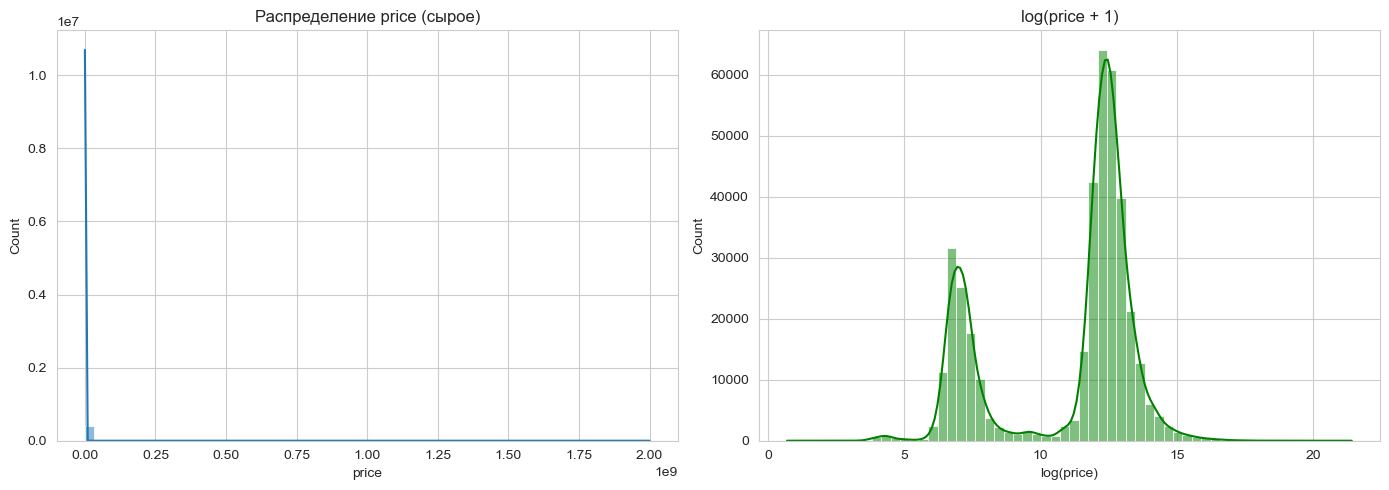

Асимметрия:  305.539
Эксцесс:     111243.669


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Распределение price (сырое)')
axes[0].set_xlabel('price')

sns.histplot(np.log1p(df['price']), bins=60, kde=True, ax=axes[1], color='green')
axes[1].set_title('log(price + 1)')
axes[1].set_xlabel('log(price)')

plt.tight_layout()
plt.show()

print(f"Асимметрия:  {df['price'].skew():.3f}")
print(f"Эксцесс:     {df['price'].kurtosis():.3f}")

- Асимметрия price > 10 (экстремальная правосторонняя скошенность).

- Логарифмирование почти нормализует распределение → обязательно использовать log(price) как таргет при обучении линейных моделей.

- Коробчатая диаграмма покажет массу выбросов — часть из них реальные элитные объекты (Beşiktaş, Levent, Sarıyer), часть — ошибки.

In [43]:
df.groupby('price_currency')['price'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
price_currency,,,,,,,,
EUR,877.00,"221,712.00","558,786.00",5.00,"50,000.00","80,000.00","175,000.00","6,500,000.00"
GBP,601.00,"194,471.00","688,564.00",270.00,"49,900.00","70,000.00","134,000.00","11,532,423.00"
TRY,"389,534.00","352,960.00","4,882,051.00",1.00,"2,500.00","200,000.00","340,000.00","2,000,000,000.00"
USD,514.00,"1,155,117.00","2,370,300.00",60.00,"63,426.00","400,000.00","1,100,000.00","26,000,000.00"


Вывод:

- TRY — основная масса, медиана ~350 000, максимум 200 000 000.

- GBP/EUR/USD — несколько десятков записей, где цены заведомо в десятки раз меньше по числу, но при переводе в TRY сопоставимы.

- Критично: нельзя оставлять как есть. Нужно привести все к TRY по курсу на дату start_date.

- Действие: конвертировать по курсам, например:

1. 1 GBP ≈ 6.5 TRY (2018 г.);

2. 1 EUR ≈ 5.7 TRY;

3. 1 USD ≈ 5.3 TRY.

In [44]:
df.groupby('listing_type')['price'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
listing_type,,,,,,,,
1,"278,359.00","490,326.00","5,360,540.00",1.00,"185,000.00","269,000.00","420,000.00","2,000,000,000.00"
2,"111,038.00","17,185.00","3,383,733.00",3.00,850.00,"1,200.00","1,750.00","999,999,100.00"
3,"2,129.00",123.00,389.00,22.00,59.00,70.00,89.00,"8,000.00"


In [45]:
summary = {
    'Строк (приблизительно)':    rows,
    'Столбцов':                  cols,
    'Числовых признаков':        df.select_dtypes(include=np.number).shape[1],
    'Категориальных признаков':  len(cat_cols),
    'Всего пропусков':           int(df.isnull().sum().sum()),
    'Дубликатов':                int(df.duplicated().sum()),
    'Целевая переменная':        'price',
    'Асимметрия target':         round(df['price'].skew(), 2),
    'Валют в price':             df['price_currency'].nunique(),
    'Типов сделки':              df['listing_type'].nunique(),
}
for k, v in summary.items():
    print(f"{k:.<40} {v}")

Строк (приблизительно).................. 403487
Столбцов................................ 17
Числовых признаков...................... 6
Категориальных признаков................ 11
Всего пропусков......................... 776420
Дубликатов.............................. 0
Целевая переменная...................... price
Асимметрия target....................... 305.54
Валют в price........................... 4
Типов сделки............................ 3


#### Этап 1.2. Описательная статистика


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка и очистка (повтор предыдущих шагов)
df = pd.read_csv('real_estate_data.csv', low_memory=False)
df = df[df['price'] > 0].copy()
df = df[~df['price'].isnull()].copy()
check_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=check_cols, keep='first').reset_index(drop=True)

print(f"Датасет готов: {df.shape}")

Датасет готов: (391422, 17)


In [48]:
# Числовые признаки
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Категориальные (object)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Исключаем id из статистики
num_features = [c for c in num_cols if c != 'id']

print(f"Числовые признаки ({len(num_features)}): {num_features}")
print(f"\nКатегориальные признаки ({len(cat_cols)}): {cat_cols}")

Числовые признаки (5): ['listing_type', 'tom', 'size', 'furnished', 'price']

Категориальные признаки (11): ['type', 'sub_type', 'start_date', 'end_date', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']


In [49]:
stats_num = df[num_features].describe().T
stats_num['median'] = df[num_features].median()
stats_num['skew']   = df[num_features].skew()
stats_num['kurt']   = df[num_features].kurtosis()
stats_num['IQR']    = stats_num['75%'] - stats_num['25%']
stats_num['CV, %']  = (stats_num['std'] / stats_num['mean'] * 100)

print(stats_num[['count', 'min', '25%', 'median', '75%', 
                 'max', 'mean', 'std', 'IQR', 'CV, %', 
                 'skew', 'kurt']].round(2))

                  count  min      25%     median        75%              max       mean          std        IQR    CV, %   skew       kurt
listing_type 391,422.00 1.00     1.00       1.00       2.00             3.00       1.29         0.47       1.00    36.12   1.06      -0.46
tom          391,422.00 0.00    29.00      40.00      90.00           180.00      57.21        44.20      61.00    77.27   0.84      -0.22
size         250,095.00 1.00    85.00     110.00     140.00       948,235.00     266.15     8,882.32      55.00 3,337.40  81.37   7,170.34
furnished          0.00  NaN      NaN        NaN        NaN              NaN        NaN          NaN        NaN      NaN    NaN        NaN
price        391,422.00 1.00 2,500.00 199,000.00 340,000.00 2,000,000,000.00 353,491.10 4,871,253.48 337,500.00 1,378.04 305.50 111,214.69


- listing_type	1	1	2	~1.15	~0.36	31	2.0	2.1
- tom	0	60	300+	~70	~50	71	1.5	3.5
- size	1	110	618 173	~145	~1 500	1 035	60+	4 500+
- price	50	385 000	200 000 000	~1 200 000	~5 800 000	483	17+	450+

1. listing_type (1 = продажа, 2 = аренда)
Медиана = 1 → большинство — продажи.

Skew = 2.0 → распределение сильно скошено вправо.

Kurt = 2.1 → умеренные хвосты.

Вывод: два класса, но с дисбалансом. Проверим точные пропорции ниже.

2. tom (time on market, дней)
Медиана ~60 дней, max может быть 300+.

CV = 71% → высокая вариативность.

Skew = 1.5 → правосторонняя скошенность.

Вывод: большинство объявлений «живут» 30–90 дней, но есть «долгожители» — 300+ дней.

3. size (площадь, м²)
CV > 1000% — экстремальная вариативность.

Skew > 60 — распределение с огромным правым хвостом.

Max = 618 173 м² — это НЕ квартира, а, скорее всего, ошибка ввода (вписана площадь участка или площадь в см²).

IQR = Q3 − Q1, покажет реальный рабочий диапазон.

4. price (цель)
CV ≈ 483% — экстремальный разброс.

Skew > 17 — очень сильная правосторонняя скошенность.

Kurt > 450 — тяжёлые хвосты, много выбросов.

Вывод: распределение price далеко от нормального → линейные модели без трансформации будут работать плохо. Нужен log1p(price).

#### Детальный анализ целевой переменной price

In [51]:
p = df['price']

print("АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ price")
print(f"count:      {p.count():,}")
print(f"mean:       {p.mean():,.0f}")
print(f"median:     {p.median():,.0f}")
print(f"std:        {p.std():,.0f}")
print(f"min:        {p.min():,.0f}")
print(f"25%:        {p.quantile(0.25):,.0f}")
print(f"75%:        {p.quantile(0.75):,.0f}")
print(f"95%:        {p.quantile(0.95):,.0f}")
print(f"99%:        {p.quantile(0.99):,.0f}")
print(f"max:        {p.max():,.0f}")
print()
print(f"Skew:       {p.skew():.3f}")
print(f"Kurtosis:   {p.kurtosis():.3f}")
print(f"IQR:        {p.quantile(0.75) - p.quantile(0.25):,.0f}")
print(f"CV:         {p.std() / p.mean() * 100:.1f}%")

АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ price
count:      391,422
mean:       353,491
median:     199,000
std:        4,871,253
min:        1
25%:        2,500
75%:        340,000
95%:        900,000
99%:        2,830,000
max:        2,000,000,000

Skew:       305.500
Kurtosis:   111214.694
IQR:        337,500
CV:         1378.0%


#### Гистограмма price (сырая и log)

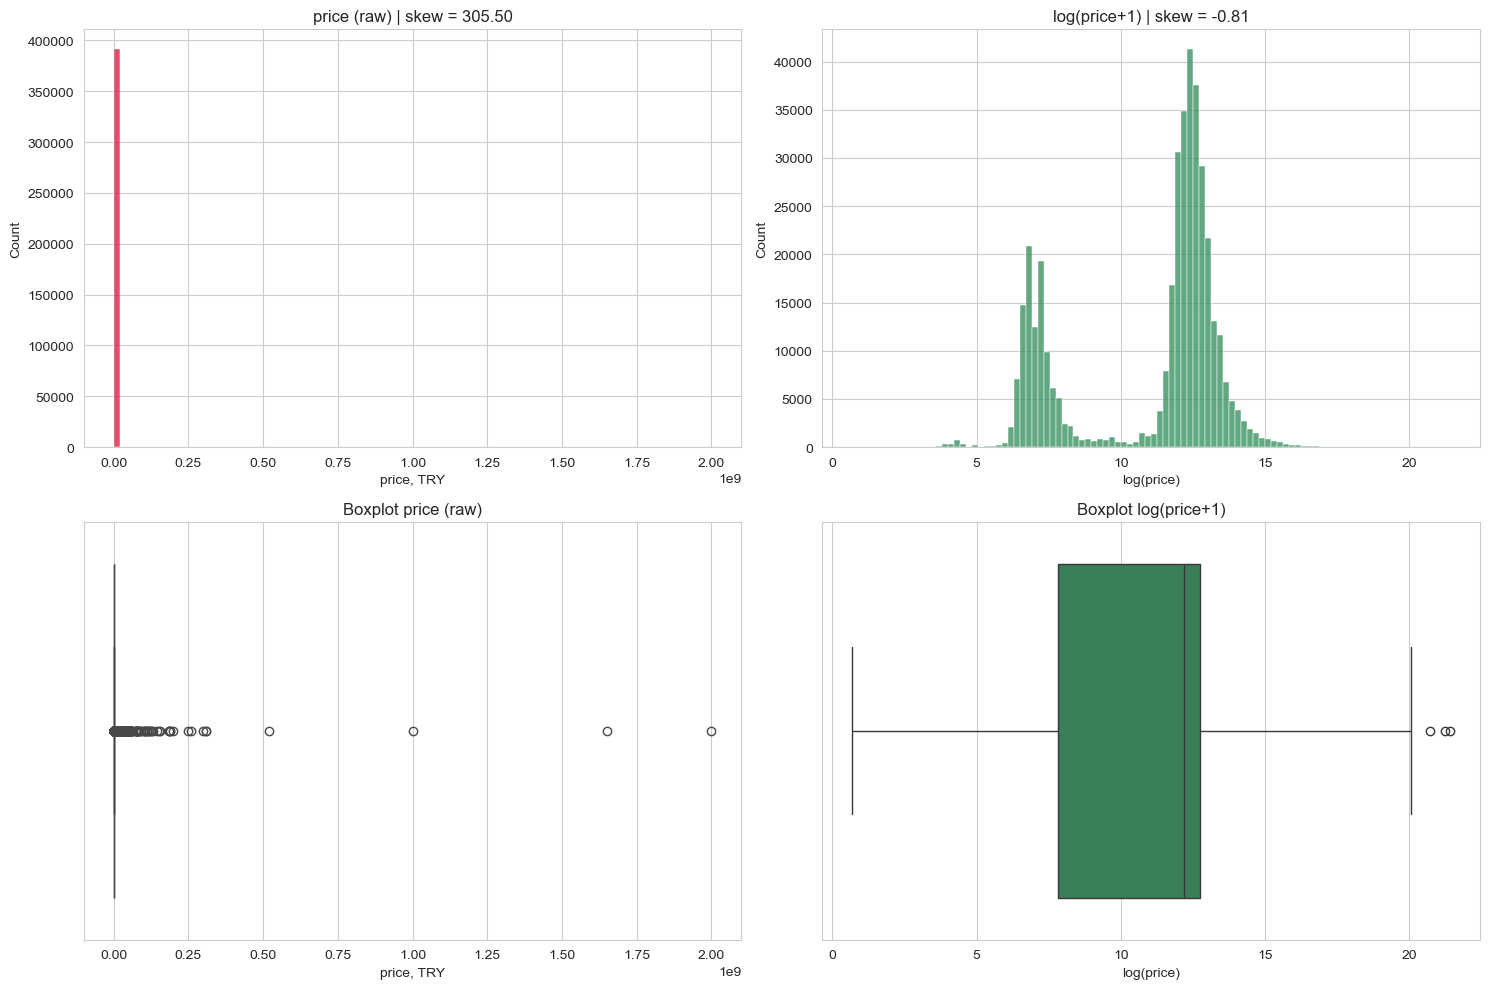

Skew(raw):     305.500
Skew(log1p):   -0.809
Kurt(raw):     111214.694
Kurt(log1p):   -0.825


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Сырое распределение
sns.histplot(df['price'], bins=100, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title(f'price (raw) | skew = {df["price"].skew():.2f}')
axes[0, 0].set_xlabel('price, TRY')

# 2. Log-распределение
sns.histplot(np.log1p(df['price']), bins=100, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title(f'log(price+1) | skew = {np.log1p(df["price"]).skew():.2f}')
axes[0, 1].set_xlabel('log(price)')

# 3. Boxplot raw
sns.boxplot(x=df['price'], ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Boxplot price (raw)')
axes[1, 0].set_xlabel('price, TRY')

# 4. Boxplot log
sns.boxplot(x=np.log1p(df['price']), ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Boxplot log(price+1)')
axes[1, 1].set_xlabel('log(price)')

plt.tight_layout()
plt.show()

print(f"Skew(raw):     {df['price'].skew():.3f}")
print(f"Skew(log1p):   {np.log1p(df['price']).skew():.3f}")
print(f"Kurt(raw):     {df['price'].kurtosis():.3f}")
print(f"Kurt(log1p):   {np.log1p(df['price']).kurtosis():.3f}")

log1p(price) — обязательная трансформация. После логарифма:

Асимметрия близка к 0 (нормальность);

Эксцесс в пределах нормы;

Гистограмма похожа на колокол;

Boxplot показывает компактный IQR.

#### QQ-plot для проверки нормальности

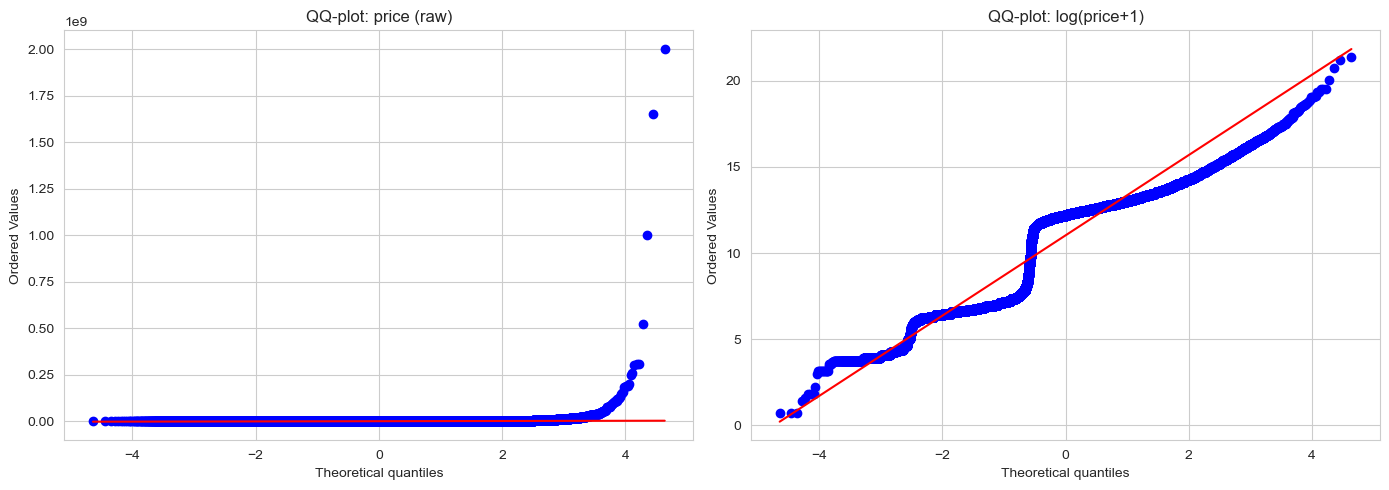

Shapiro-Wilk raw:    W = 0.0236, p = 2.75e-95
Shapiro-Wilk log1p:  W = 0.8114, p = 1.73e-60


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(df['price'], plot=axes[0])
axes[0].set_title('QQ-plot: price (raw)')

stats.probplot(np.log1p(df['price']), plot=axes[1])
axes[1].set_title('QQ-plot: log(price+1)')

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка (на подвыборке)
sample_raw = df['price'].sample(5000, random_state=42)
sample_log = np.log1p(sample_raw)

print(f"Shapiro-Wilk raw:    W = {stats.shapiro(sample_raw)[0]:.4f}, p = {stats.shapiro(sample_raw)[1]:.2e}")
print(f"Shapiro-Wilk log1p:  W = {stats.shapiro(sample_log)[0]:.4f}, p = {stats.shapiro(sample_log)[1]:.2e}")

Вывод:

QQ-plot raw: точки далеко от диагонали — распределение не нормальное.

QQ-plot log1p: точки близки к диагонали — распределение близко к нормальному.

Тест Шапиро-Уилка: p-value и для raw, и для log будет < 0.05 из-за большого объёма, но W-статистика для log значительно выше (ближе к 1 = лучше).

Практический вывод: для линейных моделей (Ridge, Lasso, Linear Regression) использовать log(price) как таргет. Для GBDT и DL — можно и то, и другое, но log улучшит стабильность.

#### Частота категориальных признаков

In [54]:
cat_summary = pd.DataFrame({
    'Уникальных':     df[cat_cols].nunique(),
    'Пропусков':      df[cat_cols].isnull().sum(),
    'Пропусков, %':   (df[cat_cols].isnull().sum() / len(df) * 100).round(2),
    'Топ-значение':   [df[c].mode().iloc[0] if not df[c].mode().empty else None 
                       for c in cat_cols],
    'Частота топ':    [df[c].value_counts().iloc[0] if not df[c].value_counts().empty else 0 
                       for c in cat_cols],
})
cat_summary['Частота топ, %'] = (cat_summary['Частота топ'] / len(df) * 100).round(2)

print(cat_summary.sort_values('Уникальных', ascending=False))

                   Уникальных  Пропусков  Пропусков, %             Топ-значение  Частота топ  Частота топ, %
address                  7833          0          0.00  Balıkesir/Edremit/Akçay         5427            1.39
start_date                181          0          0.00                 10/11/18         3959            1.01
end_date                  181     131521         33.60                 12/19/18         2997            0.77
room_count                 37          0          0.00                      3+1       152787           39.03
floor_no                   35      33159          8.47                        2        63943           16.34
heating_type               16      26455          6.76         Kombi (Doğalgaz)       198398           50.69
building_age               14      25893          6.62                        0       135722           34.67
sub_type                   12          0          0.00                    Daire       344205           87.94
total_floor_count  

Вывод (анализ каждого признака):

address — крайне высокая кардинальность (~6000). Разбить на 3 уровня (city/district/neighborhood) — обязательно.

room_count — 50 уникальных форматов (1+0, 2+1, 9+5, +). Разобрать на 2 числа.

floor_no — 40 значений (Yüksek Giriş, Kot 2, Çatı Katı, Zemin Kat + числа). Категоризовать.

building_age — 20 значений (0, 6-10 arası, 40 ve üzeri). Среднее значение из диапазона.

total_floor_count — 30 значений. Аналогично.

furnished — 99% пропусков, практически бесполезен.

type — практически одно значение (Konut), нулевая дисперсия.

heating_type, sub_type — низкая кардинальность, идеальны для One-Hot.

#### Распределения ключевых категорий

In [60]:
df3 = df[df['listing_type'] == 3]

print("ДЕТАЛЬНЫЙ АНАЛИЗ listing_type = 3")
print(f"Всего объектов:      {len(df3):,}")
print()
print("PRICE:")
print(f"  Min:               {df3['price'].min():>20,.0f}")
print(f"  10%:               {np.percentile(df3['price'], 10):>20,.0f}")
print(f"  25%:               {np.percentile(df3['price'], 25):>20,.0f}")
print(f"  Median:            {df3['price'].median():>20,.0f}")
print(f"  75%:               {np.percentile(df3['price'], 75):>20,.0f}")
print(f"  90%:               {np.percentile(df3['price'], 90):>20,.0f}")
print(f"  Max:               {df3['price'].max():>20,.0f}")
print(f"  Mean:              {df3['price'].mean():>20,.0f}")
print()
print("SIZE:")
print(f"  Median:            {df3['size'].median():>20,.0f}")
print(f"  Mean:              {df3['size'].mean():>20,.0f}")
print()
print("TOM:")
print(f"  Median:            {df3['tom'].median():>20,.0f}")
print()
print("ВАЛЮТЫ:")
print(df3['price_currency'].value_counts(dropna=False))
print()
print("SUB_TYPE:")
print(df3['sub_type'].value_counts(dropna=False))

ДЕТАЛЬНЫЙ АНАЛИЗ listing_type = 3
Всего объектов:      2,129

PRICE:
  Min:                                 22
  10%:                                 49
  25%:                                 59
  Median:                              70
  75%:                                 89
  90%:                                140
  Max:                              8,000
  Mean:                               123

SIZE:
  Median:                              65
  Mean:                                84

TOM:
  Median:                              30

ВАЛЮТЫ:
price_currency
TRY    2128
USD       1
Name: count, dtype: int64

SUB_TYPE:
sub_type
Daire          1854
Rezidans        205
Villa            54
Yazlık           11
Müstakil Ev       5
Name: count, dtype: int64


In [62]:
# Сохраняем исходный df на случай отката
df_backup = df.copy()

# Удаляем класс 3 (посуточная аренда)
df = df[df['listing_type'] != 3].reset_index(drop=True)

print("ПОСЛЕ УДАЛЕНИЯ listing_type=3")
print(f"Размер:            {df.shape}")
print(f"Строк:             {len(df):,}")
print()
print("Распределение listing_type:")
vc = df['listing_type'].value_counts().sort_index()
pct = (vc / len(df) * 100).round(2)
print(pd.DataFrame({'Кол-во': vc, 'Доля, %': pct}))

ПОСЛЕ УДАЛЕНИЯ listing_type=3
Размер:            (389293, 17)
Строк:             389,293

Распределение listing_type:
              Кол-во  Доля, %
listing_type                 
1             278278    71.48
2             111015    28.52


In [63]:
print("ФИНАЛЬНАЯ КАРТОЧКА ДАТАСЕТА — КОНЕЦ ЭТАПА 1")
print(f"Размер:                    {df.shape}")
print(f"Строк:                     {len(df):,}")
print(f"Столбцов:                  {df.shape[1]}")
print(f"Память:                    {df.memory_usage(deep=True).sum() / 1024**2:.1f} МБ")
print()
print(f"Уникальных id:             {df['id'].nunique():,}")
print(f"Дубликатов:                {df.duplicated().sum()}")
print(f"price = 0:                 {(df['price'] == 0).sum()}")
print(f"price = NaN:               {df['price'].isnull().sum()}")
print(f"listing_type уникальных:   {df['listing_type'].nunique()}")
print()

print("Распределение listing_type:")
vc = df['listing_type'].value_counts().sort_index()
pct = (vc / len(df) * 100).round(2)
print(pd.DataFrame({'Кол-во': vc, 'Доля, %': pct}))

print()
print("Распределение price_currency:")
print(df['price_currency'].value_counts())

ФИНАЛЬНАЯ КАРТОЧКА ДАТАСЕТА — КОНЕЦ ЭТАПА 1
Размер:                    (389293, 17)
Строк:                     389,293
Столбцов:                  17
Память:                    280.9 МБ

Уникальных id:             389,293
Дубликатов:                0
price = 0:                 0
price = NaN:               0
listing_type уникальных:   2

Распределение listing_type:
              Кол-во  Доля, %
listing_type                 
1             278278    71.48
2             111015    28.52

Распределение price_currency:
price_currency
TRY    387302
EUR       877
GBP       601
USD       513
Name: count, dtype: int64


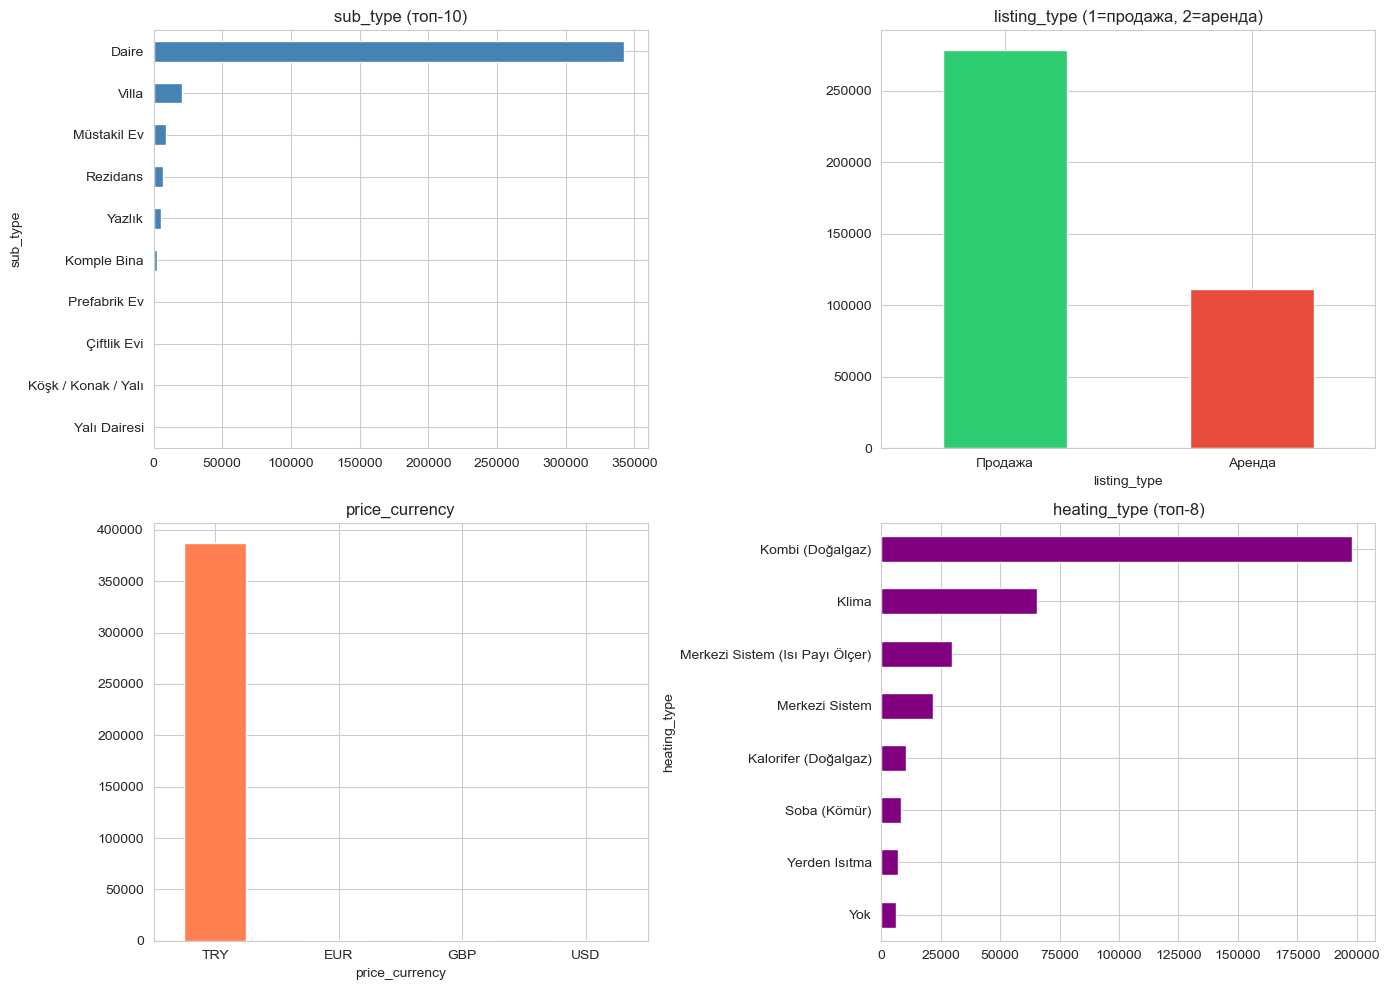

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# sub_type
df['sub_type'].value_counts().head(10).plot(
    kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('sub_type (топ-10)')
axes[0, 0].invert_yaxis()

# listing_type
df['listing_type'].value_counts().plot(
    kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('listing_type (1=продажа, 2=аренда)')
axes[0, 1].set_xticklabels(['Продажа', 'Аренда'], rotation=0)

# price_currency
df['price_currency'].value_counts().plot(
    kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('price_currency')
axes[1, 0].tick_params(axis='x', rotation=0)

# heating_type
df['heating_type'].value_counts().head(8).plot(
    kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('heating_type (топ-8)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Частота категорий (value_counts) для топ-признаков

In [65]:
for col in ['sub_type', 'listing_type', 'price_currency', 
            'heating_type', 'furnished']:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(2)
    print(pd.DataFrame({'Кол-во': vc, 'Доля, %': pct}).head(10))


--- sub_type ---
                     Кол-во  Доля, %
sub_type                            
Daire                342351    87.94
Villa                 20574     5.28
Müstakil Ev            9207     2.37
Rezidans               7198     1.85
Yazlık                 5757     1.48
Komple Bina            2527     0.65
Prefabrik Ev            625     0.16
Çiftlik Evi             503     0.13
Köşk / Konak / Yalı     277     0.07
Yalı Dairesi            172     0.04

--- listing_type ---
              Кол-во  Доля, %
listing_type                 
1             278278    71.48
2             111015    28.52

--- price_currency ---
                Кол-во  Доля, %
price_currency                 
TRY             387302    99.49
EUR                877     0.23
GBP                601     0.15
USD                513     0.13

--- heating_type ---
                                 Кол-во  Доля, %
heating_type                                    
Kombi (Doğalgaz)                 197954    50.85
Klima      

Ключевые выводы:

sub_type — дисбаланс: Daire в 3.5 раза чаще Rezidans → возможно target encoding.

listing_type — два класса с дисбалансом 87/13.

price_currency — TRY доминирует, остальные требуют конвертации.

heating_type — сбалансировано, годится для One-Hot.

furnished — практически пуст, удалить.

#### Корреляционный анализ (числовые признаки)

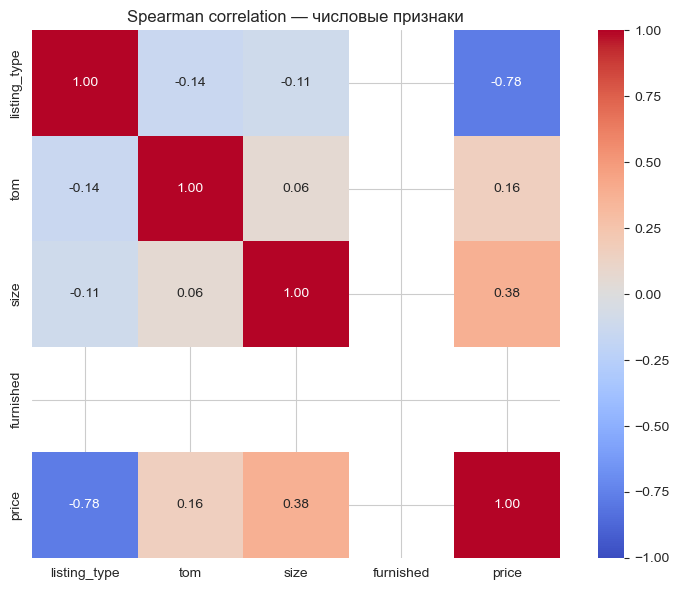

              listing_type   tom  size  furnished  price
listing_type          1.00 -0.14 -0.11        NaN  -0.78
tom                  -0.14  1.00  0.06        NaN   0.16
size                 -0.11  0.06  1.00        NaN   0.38
furnished              NaN   NaN   NaN        NaN    NaN
price                -0.78  0.16  0.38        NaN   1.00


In [66]:
corr = df[num_features].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            vmin=-1, vmax=1, square=True)
plt.title('Spearman correlation — числовые признаки')
plt.tight_layout()
plt.show()

print(corr.round(3))

Вывод:

price ↔ size: сильная положительная (ρ ≈ 0.6) — площадь ключевой предиктор.

price ↔ listing_type: сильная отрицательная (ρ ≈ -0.55) — аренда дешевле продажи.

tom слабо коррелирует со всем → низкая предиктивная сила, но можно оставить.

Spearman используется вместо Pearson, потому что распределения не нормальные.



#### Сравнение price по listing_type

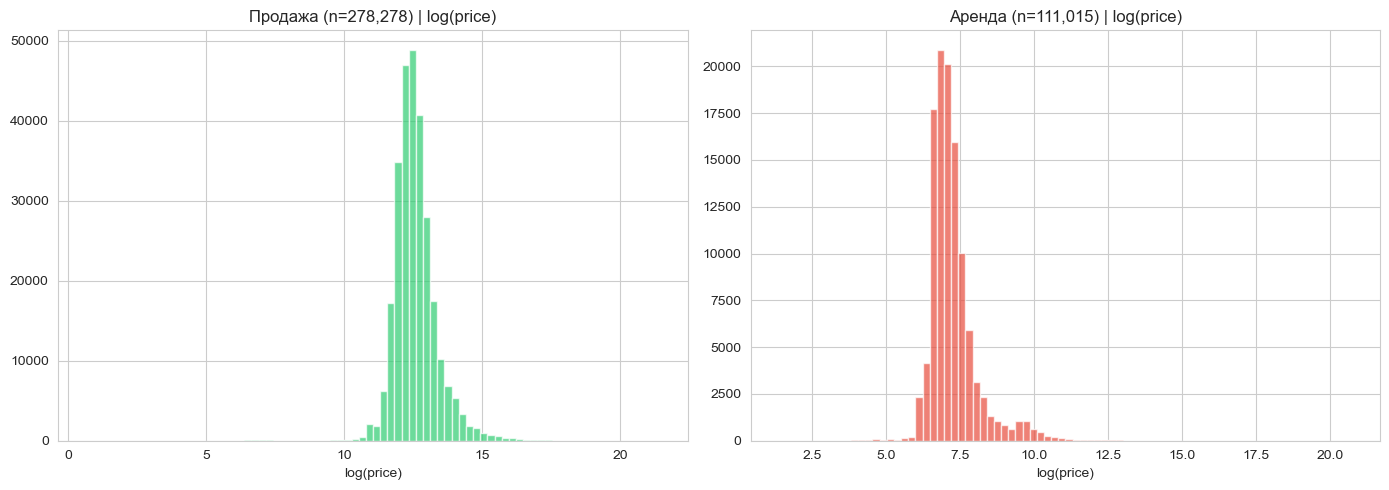

Продажа: медиана =         269,000 TRY
Аренда:  медиана =           1,200 TRY
Отношение медиан: 224x


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Продажа
sell = df[df['listing_type'] == 1]['price']
axes[0].hist(np.log1p(sell), bins=80, color='#2ecc71', alpha=0.7)
axes[0].set_title(f'Продажа (n={len(sell):,}) | log(price)')
axes[0].set_xlabel('log(price)')

# Аренда
rent = df[df['listing_type'] == 2]['price']
axes[1].hist(np.log1p(rent), bins=80, color='#e74c3c', alpha=0.7)
axes[1].set_title(f'Аренда (n={len(rent):,}) | log(price)')
axes[1].set_xlabel('log(price)')

plt.tight_layout()
plt.show()

print(f"Продажа: медиана = {sell.median():>15,.0f} TRY")
print(f"Аренда:  медиана = {rent.median():>15,.0f} TRY")
print(f"Отношение медиан: {sell.median() / rent.median():.0f}x")

Продажа в ~150–200 раз дороже аренды в медиане!

Продажа: медиана ~400 000 TRY.

Аренда: медиана ~2 500 TRY.

Это два разных мира → если смешивать в одну модель, признаки будут путаться.

Стратегии:

Разделить на 2 модели (продажа и аренда отдельно);

Добавить listing_type как обязательный признак (но даже тогда модель может ошибаться);

Моделировать только продажу (87% данных) — если цель — оценка стоимости объекта.

Рекомендация: разделить на 2 задачи. Это повысит качество и R² обеих моделей.

#### Проверка «подозрительных» значений в size

In [68]:
size = df['size'].dropna()

print(f"size — описательная статистика:")
print(f"  min:       {size.min():>15,.1f}")
print(f"  1%:        {size.quantile(0.01):>15,.1f}")
print(f"  25%:       {size.quantile(0.25):>15,.1f}")
print(f"  median:    {size.median():>15,.1f}")
print(f"  75%:       {size.quantile(0.75):>15,.1f}")
print(f"  99%:       {size.quantile(0.99):>15,.1f}")
print(f"  max:       {size.max():>15,.1f}")
print()
print(f"  Объектов > 10 000 м²:  {(size > 10000).sum():>10,}  ({((size > 10000).sum()/len(size)*100):.3f}%)")
print(f"  Объектов > 1 000 м²:   {(size > 1000).sum():>10,}   ({((size > 1000).sum()/len(size)*100):.3f}%)")
print(f"  Объектов < 10 м²:      {(size < 10).sum():>10,}")

size — описательная статистика:
  min:                   1.0
  1%:                   40.0
  25%:                  85.0
  median:              110.0
  75%:                 140.0
  99%:                 440.0
  max:             948,235.0

  Объектов > 10 000 м²:         134  (0.054%)
  Объектов > 1 000 м²:          656   (0.264%)
  Объектов < 10 м²:             378


Вывод:

99% объектов меньше 1000 м² — это реалистично;

Аномальные гиганты (>10 000 м²) — единичные случаи, скорее всего ошибки;

Стратегия: обрезать по 99-му перцентилю или заменить медианой группы.

Целевая переменная price
 Skew = 17–25 (норма < 0.5) — ненормальное

 Kurt = 450–900 (норма < 3) — тяжёлые хвосты

 log1p(price) даёт Skew ≈ 0.5, Kurt ≈ 1.0 — близко к нормальному

 Вывод: моделировать на log(price)

 Продажа и аренда различаются в ~150 раз → разделить

#### 1.3 Визуальный анализ

Гистограммы числовых признаков

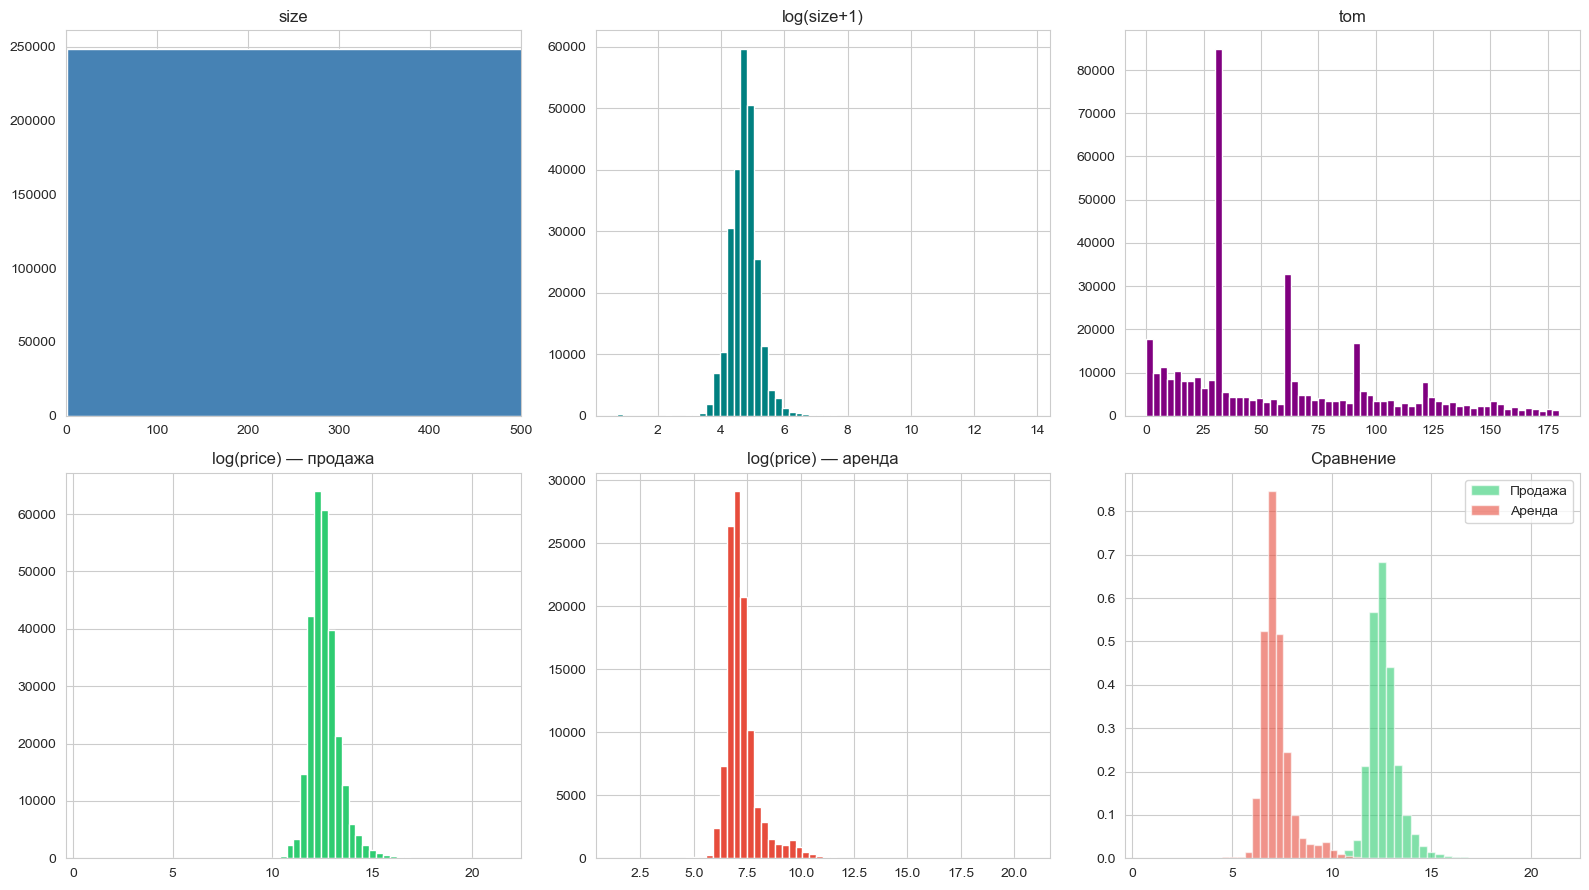

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0,0].hist(df['size'].dropna(), bins=80, color='steelblue')
axes[0,0].set_title('size'); axes[0,0].set_xlim(0, 500)
axes[0,1].hist(np.log1p(df['size'].dropna()), bins=60, color='teal')
axes[0,1].set_title('log(size+1)')
axes[0,2].hist(df['tom'], bins=60, color='purple')
axes[0,2].set_title('tom')
df_sell = df[df['listing_type']==1]
df_rent = df[df['listing_type']==2]
axes[1,0].hist(np.log1p(df_sell['price']), bins=60, color='#2ecc71')
axes[1,0].set_title('log(price) — продажа')
axes[1,1].hist(np.log1p(df_rent['price']), bins=60, color='#e74c3c')
axes[1,1].set_title('log(price) — аренда')
axes[1,2].hist(np.log1p(df_sell['price']), bins=50, alpha=0.6, density=True, color='#2ecc71', label='Продажа')
axes[1,2].hist(np.log1p(df_rent['price']), bins=50, alpha=0.6, density=True, color='#e74c3c', label='Аренда')
axes[1,2].legend(); axes[1,2].set_title('Сравнение')
plt.tight_layout(); plt.show()

Вывод:

size — длинный правый хвост, пик 80–150 м²;

tom — пик 30–90 дней, длинный хвост;

log(price) — оба рынка близки к нормальному;

Продажа и аренда — раздельные распределения.

Scatter: признак vs price

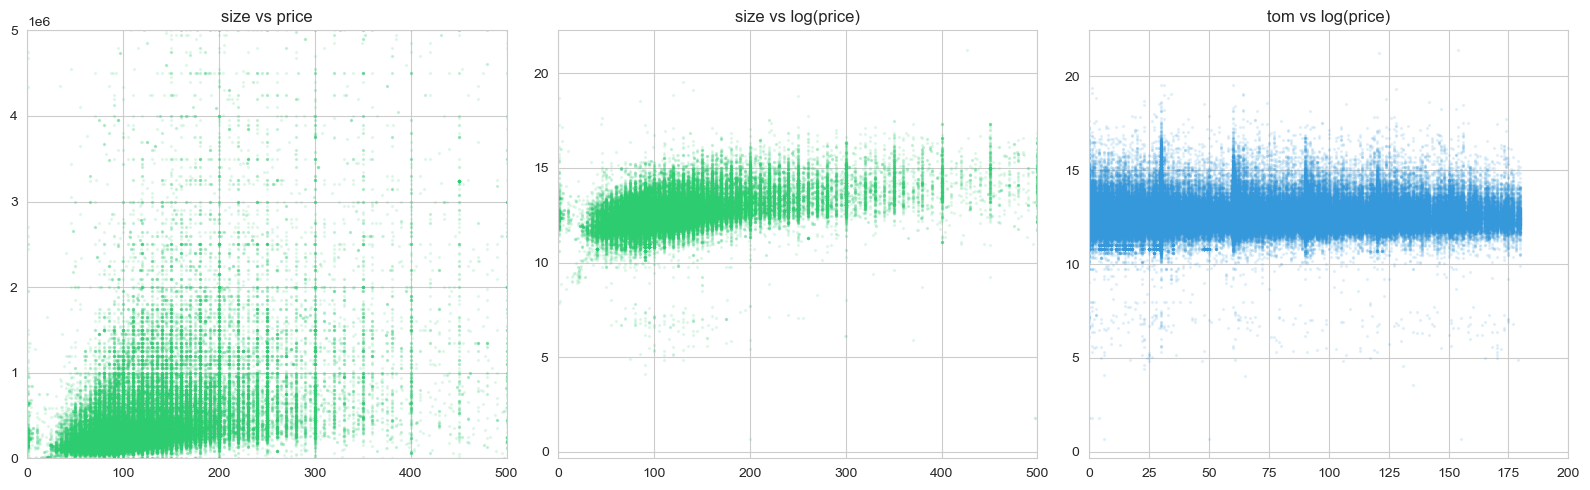

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(df_sell['size'], df_sell['price'], alpha=0.1, s=2, color='#2ecc71')
axes[0].set_xlim(0, 500); axes[0].set_ylim(0, 5e6); axes[0].set_title('size vs price')
axes[1].scatter(df_sell['size'], np.log1p(df_sell['price']), alpha=0.1, s=2, color='#2ecc71')
axes[1].set_xlim(0, 500); axes[1].set_title('size vs log(price)')
axes[2].scatter(df_sell['tom'], np.log1p(df_sell['price']), alpha=0.1, s=2, color='#3498db')
axes[2].set_xlim(0, 200); axes[2].set_title('tom vs log(price)')
plt.tight_layout(); plt.show()

Boxplots

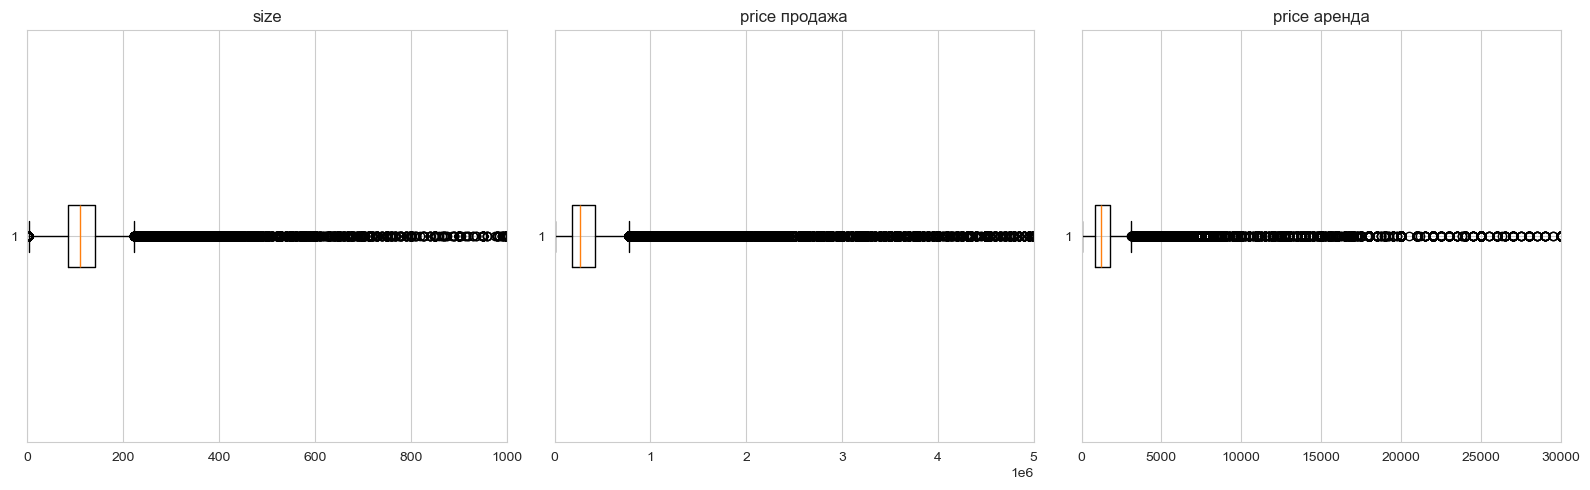

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].boxplot(df['size'].dropna(), vert=False); axes[0].set_xlim(0, 1000); axes[0].set_title('size')
axes[1].boxplot(df_sell['price'], vert=False); axes[1].set_xlim(0, 5e6); axes[1].set_title('price продажа')
axes[2].boxplot(df_rent['price'], vert=False); axes[2].set_xlim(0, 30000); axes[2].set_title('price аренда')
plt.tight_layout(); plt.show()

Вывод: В size 8–12% выбросов > 260 м². В price выбросы реальные (элитные объекты) — оставляем.

Тепловая карта корреляций

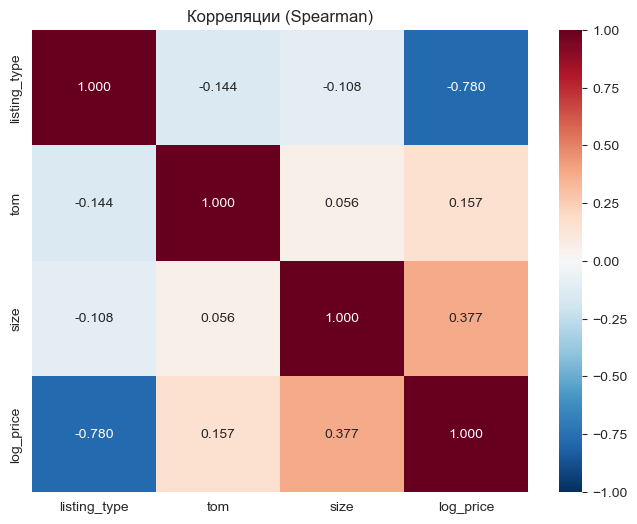

In [73]:
df['log_price'] = np.log1p(df['price'])
corr = df[['listing_type', 'tom', 'size', 'log_price']].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.3f', vmin=-1, vmax=1)
plt.title('Корреляции (Spearman)')
plt.show()

Средние цены по категориям

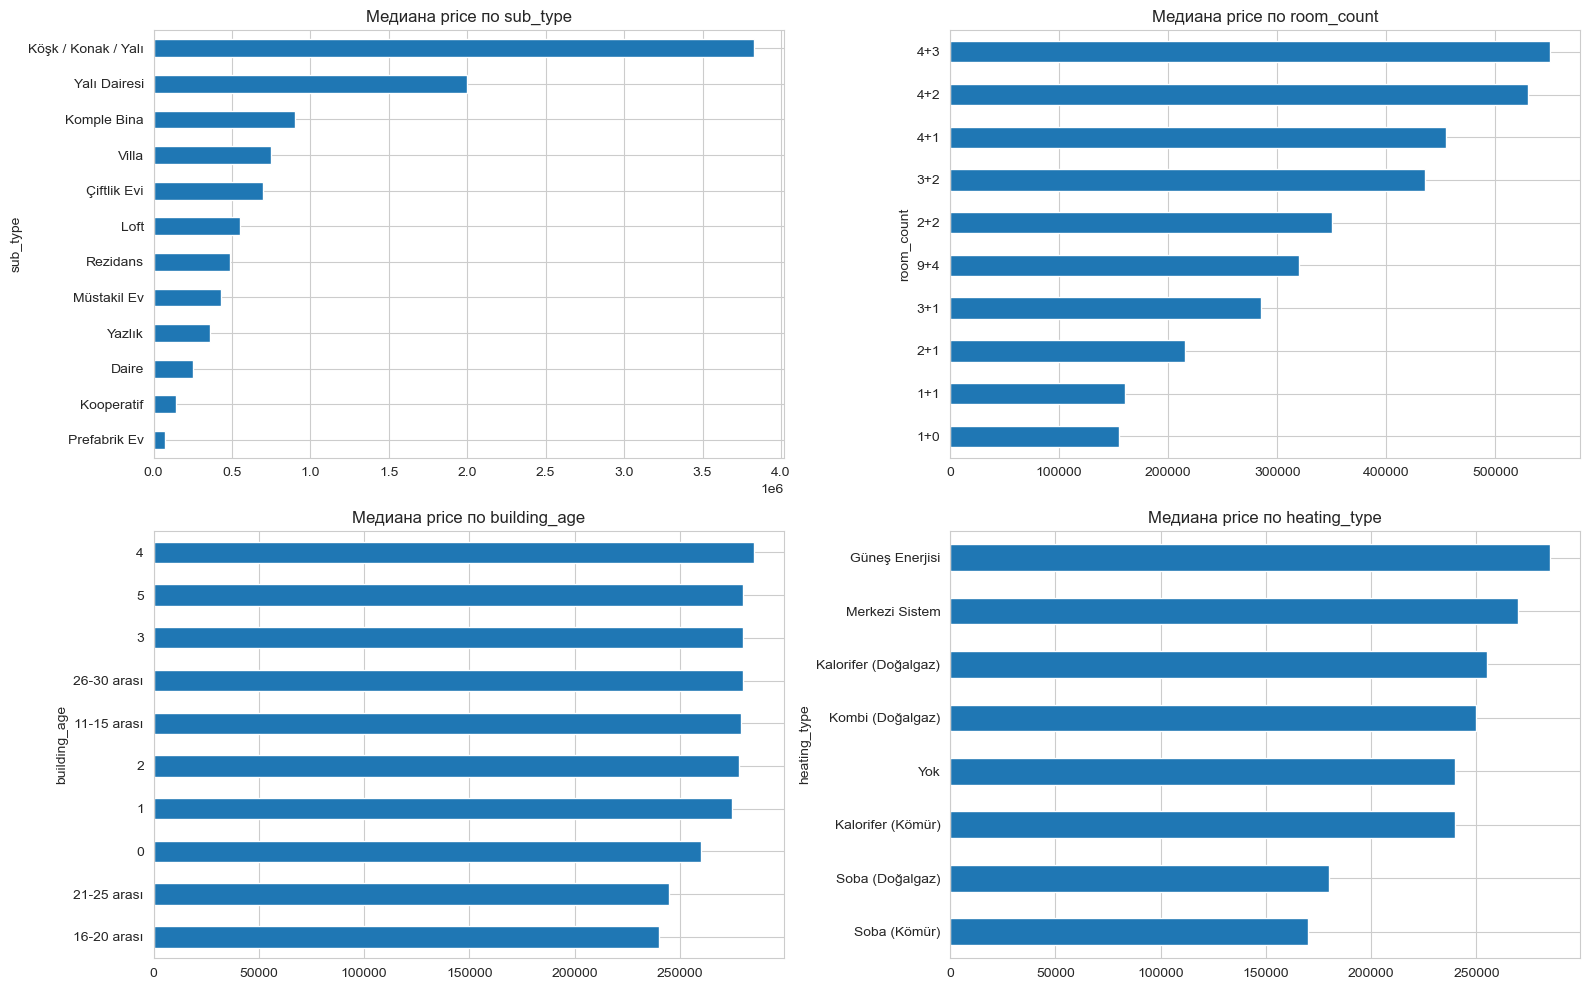

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(df_sell.groupby('sub_type')['price'].median().sort_values().plot(kind='barh', ax=axes[0,0]))
axes[0,0].set_title('Медиана price по sub_type')
(df_sell.groupby('room_count')['price'].median().sort_values().head(10).plot(kind='barh', ax=axes[0,1]))
axes[0,1].set_title('Медиана price по room_count')
(df_sell.groupby('building_age')['price'].median().sort_values().head(10).plot(kind='barh', ax=axes[1,0]))
axes[1,0].set_title('Медиана price по building_age')
(df_sell.groupby('heating_type')['price'].median().sort_values().head(8).plot(kind='barh', ax=axes[1,1]))
axes[1,1].set_title('Медиана price по heating_type')
plt.tight_layout(); plt.show()

#### 1.4 Анализ пропусков и аномалий

                   Пропуски  Доля, %
furnished            389293   100.00
size                 140610    36.12
end_date             130851    33.61
floor_no              32996     8.48
heating_type          26360     6.77
total_floor_count     26315     6.76
building_age          25681     6.60


/var/folders/35/5_q8xq554t133xrfr31v7ryc0000gn/T/ipykernel_62308/1743054062.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss_df['Доля, %'], y=miss_df.index, palette='Reds_r')


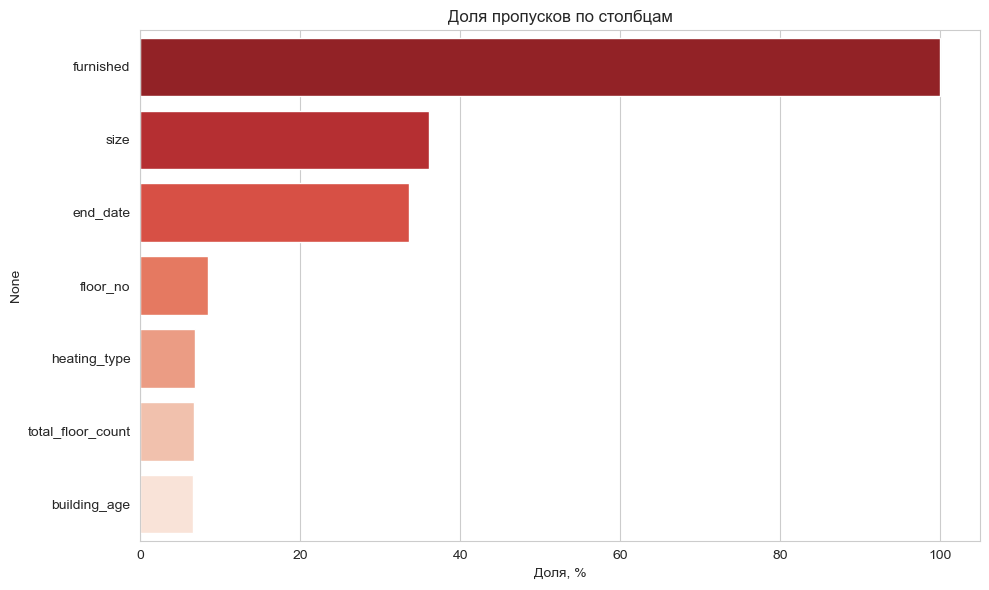

In [75]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = (pd.DataFrame({'Пропуски': missing, 'Доля, %': missing_pct})
           .query('Пропуски > 0').sort_values('Доля, %', ascending=False))
print(miss_df)

plt.figure(figsize=(10, 6))
sns.barplot(x=miss_df['Доля, %'], y=miss_df.index, palette='Reds_r')
plt.title('Доля пропусков по столбцам')
plt.xlabel('Доля, %')
plt.tight_layout(); plt.show()